<a href="https://colab.research.google.com/github/skang0812/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

In [13]:
!rm -rf scratchpad
!git clone https://github.com/ds4e/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 31 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 24.41 MiB/s, done.
Resolving deltas: 100% (56/56), done.


<Figure size 640x480 with 0 Axes>

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

Q1 Response
1. It’s linear in the parameters ($\beta$). This means the coefficients are just added together in a weighted sum. You can have non-linear features (like $x^2$), but as long as you aren't multiplying $\beta$ coefficients together, it’s a linear model.

2. The coefficient for a dummy variable tells you the difference in the average $y$ value between that specific category and the baseline category you dropped. If you keep the intercept, the dummy coefficient is the "plus or minus" relative to that intercept. If you drop the intercept, the coefficient is just the straight-up mean for that group.

3. You can by the Linear Probability Model, but it’s not great because it can predict probabilities below 0 or above 1, which makes no sense.

4. High accuracy on training data but trash performance on test data. Also, seeing massive, unstable coefficients is a huge red flag.

5. This is when your variables are too similar. In 2SLS, if your instrument is highly correlated with other controls, the model can't figure out what's actually causing the change in $y$, leading to huge errors.

6. You can add polynomials ($x^2$), interactions ($x \cdot z$), or log transformations ($\log(x)$) to catch curvy trends while keeping the model math linear.

7. It’s the average change in $y$ for every one-unit increase in $x$, holding everything else constant.

8. Train/Test is a one-time split (fast but risky). K-fold rotates the test set $k$ times so every data point gets checked (slower but way more reliable).

9. Usually 5 or 10. It’s the standard balance between being thorough and not killing your laptop's CPU.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

Q2 Response

1. Manhattan is clearly the highest at roughly 198.47.

Average Price and Scores by Neighbourhood:
                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           94.660870             91.654378
Brooklyn       129.500471             92.363497
Manhattan      198.474584             91.801785
Queens         103.222125             91.549057
Staten Island  163.462585             90.843750

The most expensive borough on average is: Manhattan


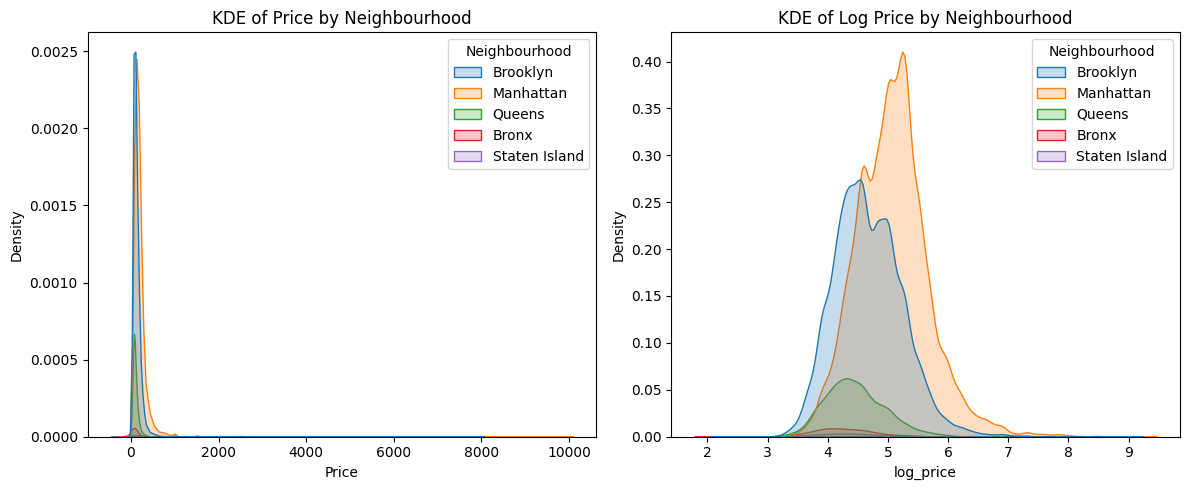

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./data/airbnb_hw.csv')
df.columns = df.columns.str.strip()

df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True).astype(float)

stats = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean(numeric_only=True)
print("Average Price and Scores by Neighbourhood:")
print(stats)

#find most expensive borough
most_expensive = stats['Price'].idxmax()
print(f"\nThe most expensive borough on average is: {most_expensive}")

plt.figure(figsize=(12, 5))

#price plot
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', fill=True)
plt.title('KDE of Price by Neighbourhood')

plt.subplot(1, 2, 2)
df['log_price'] = np.log(df['Price'])
sns.kdeplot(data=df, x='log_price', hue='Neighbourhood', fill=True)
plt.title('KDE of Log Price by Neighbourhood')

plt.tight_layout()
plt.show()

2. I dropped the Bronx as the reference group to avoid the dummy variable trap, so it’s the Intercept. If you look at Part 1, the Intercept (94.66) is the exact same as the Bronx average. The other coefficients are just the price difference from the Bronx like Manhattan being 103.81 more expensive. If you add any coefficient to the Intercept (like $94.66 + 103.81$), you get the exact group mean ($198.47$) we found earlier.

In [15]:
import statsmodels.formula.api as smf

model_nb = smf.ols(formula='Price ~ C(Neighbourhood)', data=df).fit()

print(model_nb.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     285.2
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          3.63e-241
Time:                        15:08:26   Log-Likelihood:            -2.0383e+05
No. Observations:               30478   AIC:                         4.077e+05
Df Residuals:                   30473   BIC:                         4.077e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

3. The slope coefficient is 1.0208, which basically means that for every 1-point increase in the review score, the price of an Airbnb goes up by about $1.02 on average. The intercept is 60.87, which represents the theoretical base price if a listing had a review score of zero.

In [16]:
model_reviews = smf.ols(formula='Price ~ Q("Review Scores Rating")', data=df).fit()

print(model_reviews.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.93
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.52e-19
Time:                        15:08:26   Log-Likelihood:            -1.4223e+05
No. Observations:               22155   AIC:                         2.845e+05
Df Residuals:                   22153   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

4. In this combined model, the Review Scores Rating coefficient changed slightly to 1.0811, meaning that even when we control for the neighborhood, a 1-point increase in reviews still bumps the price up by about $1.08. The neighborhood averages changed too and the fact that the review slope didn't drop much suggests that people are willing to pay for better-rated spots regardless of which borough they are in.

In [17]:
model_both = smf.ols(formula='Price ~ C(Neighbourhood) + Q("Review Scores Rating")', data=df).fit()

print(model_both.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.19e-245
Time:                        15:08:26   Log-Likelihood:            -1.4170e+05
No. Observations:               22155   AIC:                         2.834e+05
Df Residuals:                   22149   BIC:                         2.835e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

5. The slopes are not similar across all neighborhoods. While Brooklyn and Manhattan have review score slopes that are pretty close to each other, Staten Island is a huge outlier with a negative interaction of -31.83. This means that in Staten Island, the value of a higher review score is much lower than it is in the other boroughs.

In [18]:
model_puzzle = smf.ols(formula='Price ~ C(Neighbourhood) * Q("Review Scores Rating")', data=df).fit()

print(model_puzzle.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:08:26   Log-Likelihood:            -1.4150e+05
No. Observations:               22155   AIC:                         2.830e+05
Df Residuals:                   22145   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

6.

In [19]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

df_clean = df.dropna(subset=['Price', 'Neighbourhood', 'Review Scores Rating']).copy()

X4 = pd.get_dummies(df_clean[['Neighbourhood', 'Review Scores Rating']], drop_first=True)
y = df_clean['Price']

X5 = pd.get_dummies(df_clean[['Neighbourhood']], drop_first=True)
for col in X5.columns:
    X5[f'{col}_interaction'] = X5[col] * df_clean['Review Scores Rating']
X5['Review Scores Rating'] = df_clean['Review Scores Rating']

lr = LinearRegression()
cv_4 = cross_val_score(lr, X4, y, cv=10, scoring='neg_mean_squared_error')
cv_5 = cross_val_score(lr, X5, y, cv=10, scoring='neg_mean_squared_error')

print(f"Model 4 RMSE: {np.sqrt(-cv_4.mean())}")
print(f"Model 5 RMSE: {np.sqrt(-cv_5.mean())}")

Model 4 RMSE: 145.2378442072526
Model 5 RMSE: 146.01357523845093


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


Q3 Response

1.
SUVs are the most expensive by a long shot, with a mean price of about 1.17 million rupees. SUVs also have the most variance (highest std of about 417,479). This makes sense because SUVs can range from budget models to highend luxury ones.

Price Summary:
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

Price by Body Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000

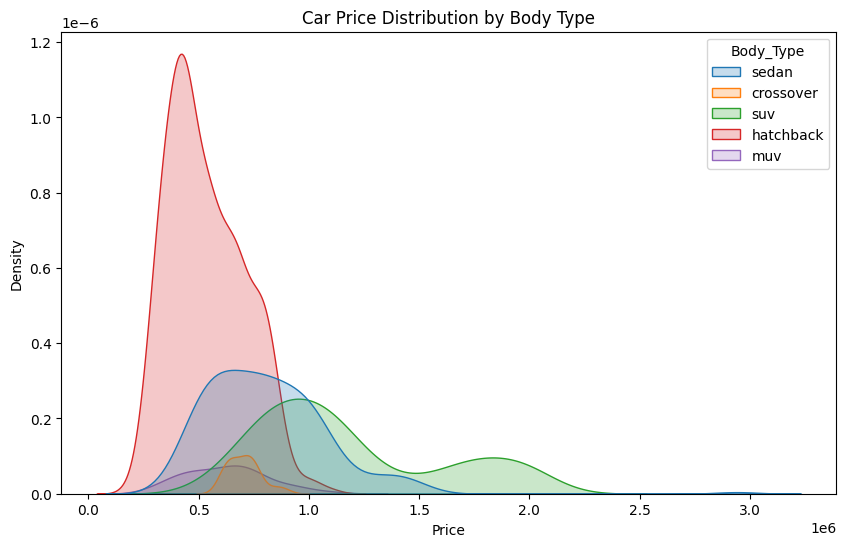

In [20]:
#load data
cars = pd.read_csv('./data/cars_hw.csv')

print("Price Summary:")
print(cars['Price'].describe())

body_stats = cars.groupby('Body_Type')['Price'].describe()
print("\nPrice by Body Type:")
print(body_stats)

#grouped KDE Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=cars, x='Price', hue='Body_Type', fill=True)
plt.title('Car Price Distribution by Body Type')
plt.show()

2. The slope coefficient in the linear model is 59,270. However, the relationship isn't actually linear. When looking at the Categorical Model, the price jumps are all over the place. For example, the coefficient for a 6-seater is 1.45 million, but for a 7-seater, it drops significantly to 735k. This shows that seating capacity doesn't have a consistent per seat price increase.

In [21]:
import statsmodels.formula.api as smf

model_seats_num = smf.ols(formula='Price ~ Seating_Capacity', data=cars).fit()
print("--- Linear Model ---")
print(model_seats_num.summary())

model_seats_cat = smf.ols(formula='Price ~ C(Seating_Capacity)', data=cars).fit()
print("\n--- Categorical Model ---")
print(model_seats_cat.summary())

--- Linear Model ---
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0245
Time:                        15:08:27   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          

3.

In [22]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

#create Age variable
cars['Age'] = 2026 - cars['Make_Year']

#test powers from 1 to 5
X = cars[['Age']]
y = cars['Price']
results = {}

for p in range(1, 6):
    poly = PolynomialFeatures(degree=p)
    X_poly = poly.fit_transform(X)

    lr = LinearRegression()

    cv_scores = cross_val_score(lr, X_poly, y, cv=10, scoring='neg_mean_squared_error')
    results[p] = np.sqrt(-cv_scores.mean())

best_degree = min(results, key=results.get)
print(f"Optimal number of powers: {best_degree}")
print("RMSE for each degree:", results)

Optimal number of powers: 5
RMSE for each degree: {1: np.float64(316694.4427669286), 2: np.float64(317513.1817679725), 3: np.float64(316828.2864453831), 4: np.float64(316977.0198627998), 5: np.float64(316435.37443412456)}


4. The model captures the general downward trend as cars get older, but it definitely looks like it's over-fitting in some spots. Since we used a 5th degree polynomial, the red line is squiggling to hit specific clusters of data rather than showing a smooth, realistic depreciation curve.

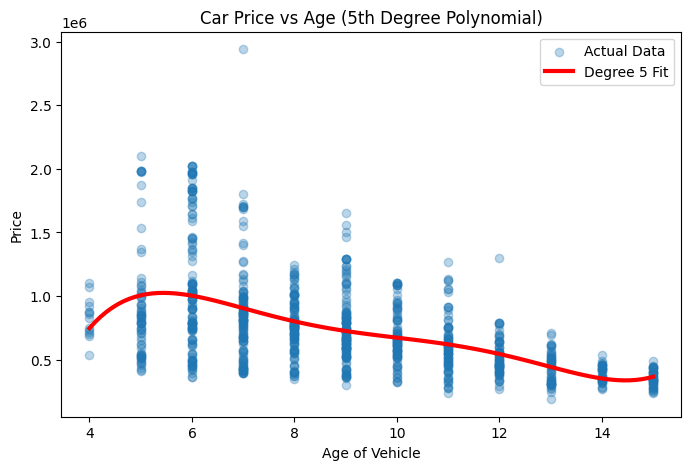

In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas

# Load the cars DataFrame and create 'Age' variable as they are needed in this cell
cars = pd.read_csv('./data/cars_hw.csv')
cars['Age'] = 2026 - cars['Make_Year']

# Redefine X and y to ensure they are available in this cell
X = cars[['Age']]
y = cars['Price']

poly_final = PolynomialFeatures(degree=5)
X_poly_final = poly_final.fit_transform(X.values)
model_final = LinearRegression().fit(X_poly_final, y)

age_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model_final.predict(poly_final.transform(age_range))

plt.figure(figsize=(8, 5))
plt.scatter(cars['Age'], cars['Price'], alpha=0.3, label='Actual Data')
plt.plot(age_range, y_pred, color='red', linewidth=3, label='Degree 5 Fit')
plt.xlabel('Age of Vehicle')
plt.ylabel('Price')
plt.title('Car Price vs Age (5th Degree Polynomial)')
plt.legend()
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


Q4 Response

1. The control group survival is at 12.28% and the treatment group at 45.07%, giving you an ATE of 0.3279.

In [24]:
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

#load data
heart = pd.read_csv('heart_hw.csv')

#calculate mean of y for each group
prop_control = heart[heart['transplant'] == 'control']['y'].mean()
prop_treat = heart[heart['transplant'] == 'treatment']['y'].mean()
ate = prop_treat - prop_control

print(f"Control Survival Rate: {prop_control:.2%}")
print(f"Treatment Survival Rate: {prop_treat:.2%}")
print(f"Raw ATE: {ate:.4f}")

Control Survival Rate: 11.76%
Treatment Survival Rate: 34.78%
Raw ATE: 0.2302


2. The Intercept (0.1228) is exactly the survival rate of the control group, and the Treatment coefficient (0.3279) is the exact Average Treatment Effect (ATE). This proves that the regression slope is just the difference in means between the two groups.

In [25]:
model_simple = smf.ols(formula="y ~ C(transplant, Treatment('control'))", data=heart).fit()

print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0133
Time:                        15:08:28   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

3. When we control for age, the ATE actually increases slightly to 0.3459. The age coefficient of -0.0149 means that for every year older a patient is, their survival probability decreases by about 1.5%, regardless of whether they got a transplant. The Intercept (0.7811) is now the predicted survival rate for a 0 year old in the control group, which is just a theoretical baseline.

In [26]:
model_age = smf.ols(formula="y ~ C(transplant, Treatment('control')) + age", data=heart).fit()

print(model_age.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           0.000357
Time:                        15:08:28   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

4. The interaction coefficient is -0.0039, which is negative but very small. This tells us that the transplant’s effectiveness actually decreases slightly as patients get older, but not by much.

In [27]:
model_puzzle = smf.ols(formula="y ~ C(transplant, Treatment('control')) * age", data=heart).fit()

print(model_puzzle.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           0.000310
Time:                        15:08:28   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

5. Using 10-fold cross-validation, the Interaction Model achieved a lower RMSE (0.3804) compared to the Age Model (0.3846). This indicates that accounting for how the transplant's effect varies with age leads to more accurate predictions of patient survival.

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

#setup
X_age = pd.get_dummies(heart[['transplant', 'age']], drop_first=True)
X_inter = X_age.copy()
X_inter['interaction'] = X_inter['transplant_treatment'] * X_inter['age']
y = heart['y']

#run CV
lr = LinearRegression()
cv_age = cross_val_score(lr, X_age, y, cv=10, scoring='neg_mean_squared_error')
cv_inter = cross_val_score(lr, X_inter, y, cv=10, scoring='neg_mean_squared_error')

print(f"Age Model RMSE: {np.sqrt(-cv_age.mean())}")
print(f"Interaction Model RMSE: {np.sqrt(-cv_inter.mean())}")

Age Model RMSE: 0.4463497064996494
Interaction Model RMSE: 0.44282966680341945


6. One concern is that using this model to prioritize transplants could lead to age-based discrimination. Since survival probability drops as age increases, the model might systematically deprioritize older patients, which raises huge ethical issues about fairness vs. utility. It also suffers from omitted variable bias because it ignores critical medical factors like blood type or other health conditions. Plus, using a Linear Probability Model for life-or-death decisions is risky since it can predict impossible probabilities (like below 0 or above 1), making it pretty unreliable for actual deployment.